# Retrieval-Augmented Generation (RAG)

É um método de combinação de _corpus_ com AI generativa de texto, buscando aumentar a acurácia segundo textos fornecidos.
A preocupação desse método é com a generalização que as AIs generativas respondem, pois cada método foi treinado com bilhões de textos que divergem muito de temática. Além disso, como as AIs generativas tem aplicações em diversos campos do conhecimento, quanto mais "contexto" é fornecido para a AI, maior a acurácia da sua resposta.

Qual o ganho com o RAG?
* O RAG vai buscar contextos mais próximos com a pergunta feita à AI no _corpus_ fornecido, indicando assim algumas informações mais próximas do contexto da pergunta.

Quais os passos do RAG?
1. **Inserção do _corpus_ de referência**: Quais tipos de informação será usado?
2. **Tratamento do _corpus_**: Como vai ser tratado o recorte dos dados?
3. **Vetorização (_embedding_)**: Quais os dados comparativos para estabelecer o contexto dos recortes?
4. **Recuperação de informação do _corpus_**: Quais recortes possuem uma maior proximidade com a pergunta feita?
5. **_Input_ e _Output_ da LLM**.

Usaremos como base as ferramentas do LangChain https://python.langchain.com/docs/how_to/

## Inserção do _corpus_ de referência

Nessa seção, vamos olhar primeiro como inserir e transformar os textos de referência para o RAG.
* Leitura e tratamento de dados em pdf;
* Leitura de páginas de internet;

In [ ]:
%pip install pymupdf langchain_community langchain_text_splitters langchain_experimental langchain langchain_core typing_extensions
# %pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu128
%pip install -qU langchain-pinecone

Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com
  Attempting uninstall: langsmith
    Found existing installation: langsmith 0.4.31
    Uninstalling langsmith-0.4.31:
      Successfully uninstalled langsmith-0.4.31
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [2]:
import pymupdf
import os

def extract_text_from_pdf(pdf_path):
    #Extracts text from a PDF file and prints the first `num_chars` characters.

    # Open the PDF file
    mypdf = pymupdf.open(pdf_path)
    all_text = ""  # Initialize an empty string to store the extracted text

    # Iterate through each page in the PDF
    for page_num in range(mypdf.page_count):
        page = mypdf[page_num]  # Get the page
        text = page.get_text("text")  # Extract text from the page
        all_text += text  # Append the extracted text to the all_text string
    return all_text

In [4]:
corpus = list()

for arquivo in os.listdir('dados_juridicos'):
    if arquivo.endswith('.pdf'):
        pdf_path = os.path.join('dados_juridicos', arquivo)
        text = extract_text_from_pdf(pdf_path)
        corpus.append(text)

print(corpus[0])

TRIBUNAL DE JUSTIÇA DO ESTADO DE SÃO PAULO
COMARCA DE LUCÉLIA
FORO DE LUCÉLIA
2ª VARA
Praça José Firpo, . - Centro
CEP: 17780-000 - Lucelia - SP
Telefone: (18) 3551-1155 - E-mail: lucelia2@tjsp.jus.br
      
0000003-95.2018.8.26.0592 - lauda 1
SENTENÇA
Processo nº:
0000003-95.2018.8.26.0592
Classe - Assunto
Procedimento Especial da Lei Antitóxicos - Tráfico de Drogas 
e Condutas Afins
Autor:
Justiça Pública
Réu:
EDNA KAROLINE SOUZA BENEDICTO
Vistos.
EDNA KAROLINE SOUZA BENEDICTO, já qualificada nos 
autos, foi denunciada como incursa no artigo 33 "caput", c.c. o artigo 40, inciso III , da Lei 
11.343/06, porque no dia 31 de dezembro de 2017, por volta das 10h41min, na 
Penitenciária de Lucélia- SP, localizada na Estrada Vicinal Pachoal Milton Lentini, km 12, 
neste município de Comarca de Lucélia- SP, trazia consigo, para consumo de terceiros, 
01 (uma) porção de cocaína, com massa líquida de 120,48g, substância que causa 
dependência física e psíquica, sem autorização e em desacordo c

In [9]:
from langchain_community.document_loaders import PyPDFLoader

pages = list()
for arquivo in os.listdir("dados_juridicos"):
    pdf_path = f"dados_juridicos/{arquivo}"
    loader = PyPDFLoader(pdf_path)
    pages = pages + loader.load_and_split()

print(pages[0])

page_content='TRIBUNAL DE JUSTIÇA DO ESTADO DE SÃO PAULOCOMARCA DE LUCÉLIAFORO DE LUCÉLIA2ª VARA
Praça
 
José
 
Firpo
,
 
.
 
-
 
Centro
CEP:
 
17780-000
 
-
 
Lucelia
 
-
 
SP
Telefone:
 
(18)
 
3551-1155
 
-
 
E-mail:
 
lucelia2@tjsp.jus.br      
0000003-95.2018.8.26.0592 - lauda 1
SENTENÇAProcesso nº:0000003-95.2018.8.26.0592Classe - AssuntoProcedimento Especial da Lei Antitóxicos - Tráfico de Drogas e Condutas AfinsAutor: Justiça PúblicaRéu: EDNA KAROLINE SOUZA BENEDICTO
Vistos.EDNA KAROLINE SOUZA BENEDICTO, já qualificada nos autos, foi denunciada como incursa no artigo 33 "caput", c.c. o artigo 40, inciso III , da Lei 11.343/06, porque no dia 31 de dezembro de 2017, por volta das 10h41min, na Penitenciária de Lucélia- SP, localizada na Estrada Vicinal Pachoal Milton Lentini, km 12, neste município de Comarca de Lucélia- SP, trazia consigo, para consumo de terceiros, 01 (uma) porção de cocaína, com massa líquida de 120,48g, substância que causa dependência física e psíquica, sem a

In [5]:
%pip install beautifulsoup4

Note: you may need to restart the kernel to use updated packages.


In [11]:
import bs4
from langchain_community.document_loaders import WebBaseLoader

# Utilizando informações de páginas de internet

urls = ['https://lilianweng.github.io/posts/2023-06-23-agent/',
        'https://lilianweng.github.io/posts/2024-11-28-reward-hacking/',
        'https://lilianweng.github.io/posts/2024-04-12-diffusion-video/',
        'https://lilianweng.github.io/posts/2024-02-05-human-data-quality/',
        'https://lilianweng.github.io/posts/2024-02-05-human-data-quality/',
        'https://lilianweng.github.io/posts/2023-10-25-adv-attack-llm/']
docs = list()

for url in urls:
    loader = WebBaseLoader(
        web_paths=(url,),
        bs_kwargs=dict(
            parse_only=bs4.SoupStrainer(
                class_=("post-content", "post-title", "post-header")
            )
        ),
    )
    docs.append(loader.load())
print(docs[0])

[Document(metadata={'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/'}, page_content='\n\n      LLM Powered Autonomous Agents\n    \nDate: June 23, 2023  |  Estimated Reading Time: 31 min  |  Author: Lilian Weng\n\n\nBuilding agents with LLM (large language model) as its core controller is a cool concept. Several proof-of-concepts demos, such as AutoGPT, GPT-Engineer and BabyAGI, serve as inspiring examples. The potentiality of LLM extends beyond generating well-written copies, stories, essays and programs; it can be framed as a powerful general problem solver.\nAgent System Overview#\nIn a LLM-powered autonomous agent system, LLM functions as the agent’s brain, complemented by several key components:\n\nPlanning\n\nSubgoal and decomposition: The agent breaks down large tasks into smaller, manageable subgoals, enabling efficient handling of complex tasks.\nReflection and refinement: The agent can do self-criticism and self-reflection over past actions, learn from mistake

## **Tratamento do _corpus_**

Agora que o _corpus_ já está em um formato que o Python entende, é necessário fazer os recortes dos textos, para separar as partes de informações que indicam o que é importante recuperar e o que não possui muita relação com a pergunta.

Entre as formas de recorte, temos das mais usuais até as mais engenhosas:

* Recortes com tamanho fixo _RecursiveCharacterTextSplitter_
* Recortes a partir de caractér específico _CharacterTextSplitter_
* Recortes utilizando catacterísticas semânticas _SemanticChunker_
* Recortes enriquecidos com "títulos" do texto

In [11]:
print(docs[0])

[Document(metadata={'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/'}, page_content='\n\n      LLM Powered Autonomous Agents\n    \nDate: June 23, 2023  |  Estimated Reading Time: 31 min  |  Author: Lilian Weng\n\n\nBuilding agents with LLM (large language model) as its core controller is a cool concept. Several proof-of-concepts demos, such as AutoGPT, GPT-Engineer and BabyAGI, serve as inspiring examples. The potentiality of LLM extends beyond generating well-written copies, stories, essays and programs; it can be framed as a powerful general problem solver.\nAgent System Overview#\nIn a LLM-powered autonomous agent system, LLM functions as the agent’s brain, complemented by several key components:\n\nPlanning\n\nSubgoal and decomposition: The agent breaks down large tasks into smaller, manageable subgoals, enabling efficient handling of complex tasks.\nReflection and refinement: The agent can do self-criticism and self-reflection over past actions, learn from mistake

In [12]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

text_splitter = RecursiveCharacterTextSplitter(
    # Set a really small chunk size, just to show.
    chunk_size=1000,
    chunk_overlap=200,
    length_function=len,
    is_separator_regex=False,
)

texts = text_splitter.split_documents(docs[0])
# texts = text_splitter.split_text(corpus[0])
print(texts[0])

page_content='LLM Powered Autonomous Agents
    
Date: June 23, 2023  |  Estimated Reading Time: 31 min  |  Author: Lilian Weng


Building agents with LLM (large language model) as its core controller is a cool concept. Several proof-of-concepts demos, such as AutoGPT, GPT-Engineer and BabyAGI, serve as inspiring examples. The potentiality of LLM extends beyond generating well-written copies, stories, essays and programs; it can be framed as a powerful general problem solver.
Agent System Overview#
In a LLM-powered autonomous agent system, LLM functions as the agent’s brain, complemented by several key components:

Planning

Subgoal and decomposition: The agent breaks down large tasks into smaller, manageable subgoals, enabling efficient handling of complex tasks.
Reflection and refinement: The agent can do self-criticism and self-reflection over past actions, learn from mistakes and refine them for future steps, thereby improving the quality of final results.


Memory' metadata={'sour

Esse método é a forma mais simples de recorte de texto, ele busca tamanhos fixos de recorte e faz uma sobre prosição de texto entre os recortes. Esse método é muito útil quando a linguagem que está sendo utilizada possui algum padrão simples de pausa, final de sentença ou final de parágrafo.

Essa forma de recorte utiliza tamanhos máximos (_chunk size_), com separadores delimitados (no caso utilizamos uma quebra de linha) e _overlap_ de textos entre um recorte e outro (_chunk overlap_).
Essa forma pode ser bem útil quando possui separadores bem definidos (ex: expressões, nomes, capítulos e etc).

In [13]:
from langchain_text_splitters import CharacterTextSplitter
text_splitter = CharacterTextSplitter(
    separator=r"(fls. \d{1,3}/\d{1,3})",
    chunk_size=1000,
    chunk_overlap=200,
    length_function=len,
    is_separator_regex=True,
)
texts = text_splitter.split_documents(docs[0])
# texts = text_splitter.split_text(corpus[0])
texts[0]

Document(metadata={'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/'}, page_content='LLM Powered Autonomous Agents\n    \nDate: June 23, 2023  |  Estimated Reading Time: 31 min  |  Author: Lilian Weng\n\n\nBuilding agents with LLM (large language model) as its core controller is a cool concept. Several proof-of-concepts demos, such as AutoGPT, GPT-Engineer and BabyAGI, serve as inspiring examples. The potentiality of LLM extends beyond generating well-written copies, stories, essays and programs; it can be framed as a powerful general problem solver.\nAgent System Overview#\nIn a LLM-powered autonomous agent system, LLM functions as the agent’s brain, complemented by several key components:\n\nPlanning\n\nSubgoal and decomposition: The agent breaks down large tasks into smaller, manageable subgoals, enabling efficient handling of complex tasks.\nReflection and refinement: The agent can do self-criticism and self-reflection over past actions, learn from mistakes and refin

Nos exemplos acima, primeiro fizemos o recorte de no máximo 1000 caractéres até quando houver uma quebra de linha. Já no segundo exemplo, fizemos o recorte pelo indicador de página do arquivo, ou seja, cada pedaço do texto é uma página do pdf.

In [6]:
%pip install -qU langchain-google-genai
%pip install -qU "langchain[google-genai]"

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [8]:
import os
from langchain_experimental.text_splitter import SemanticChunker
# from langchain_openai import OpenAIEmbeddings
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_google_genai import GoogleGenerativeAIEmbeddings

os.environ["GOOGLE_API_KEY"] = google_key
# embeddings = OpenAIEmbeddings(model="text-embedding-3-large")
# embeddings = HuggingFaceEmbeddings(model_name="rufimelo/bert-large-portuguese-cased-sts")
# embeddings = HuggingFaceEmbeddings(model_name="sentence-transformers/all-mpnet-base-v2")
embeddings = GoogleGenerativeAIEmbeddings(model="models/gemini-embedding-001")

# text_splitter = SemanticChunker(embeddings, breakpoint_threshold_type="percentile", breakpoint_threshold=0.5)
text_splitter = SemanticChunker(embeddings, breakpoint_threshold_type="gradient", breakpoint_threshold_amount  = 0.5)
# text_splitter = SemanticChunker(embeddings, breakpoint_threshold_type="standard_deviation", breakpoint_threshold=0.5)

texts = text_splitter.split_documents(docs[0])
# texts = text_splitter.split_text(corpus[0])
texts[0]

GoogleGenerativeAIError: Error embedding content: 429 You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits.
* Quota exceeded for metric: generativelanguage.googleapis.com/embed_content_free_tier_requests, limit: 0 [violations {
  quota_metric: "generativelanguage.googleapis.com/embed_content_free_tier_requests"
  quota_id: "EmbedContentRequestsPerMinutePerUserPerProjectPerModel-FreeTier"
}
, links {
  description: "Learn more about Gemini API quotas"
  url: "https://ai.google.dev/gemini-api/docs/rate-limits"
}
]

O método semântico leva em consideração a ordem das palavras, utilizando estatísticas para cada nova palavra no recorte. No caso, temos 3 métodos diferentes, o percentil (aonde a próxima palavra tem que tem um percentual de probabilidade acima de x% para poder ser considerado), o gradiente, que considera não somente a ultima palavra do recorte, mas todas as palavras do recorte e por fim o desvio padrão, que considera o quanto a palavra seguinte é diferente das demais do recorte.


## **Vetorização (_embedding_)**

Dado os recortes de texto, é necessário transformar esses textos em sequência de números que permitem ser comparados. Como é necessário considerar a semântica do texto e não somente a freqüência das palavras, precisamos recorrer aos "_embeddings_", que atribui uma sequencia numérica para cada palavra e para cada recorte de texto.

In [12]:
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_experimental.text_splitter import SemanticChunker
from langchain_pinecone import PineconeVectorStore
from pinecone import Pinecone
from langchain_core.vectorstores import InMemoryVectorStore

# model_name = "rufimelo/bert-large-portuguese-cased-sts"
model_name = "sentence-transformers/all-mpnet-base-v2"
model_kwargs = {'device': 'cpu'}
# model_kwargs = {'device': 'cuda'}
encode_kwargs = {'normalize_embeddings': False}
embeddings = HuggingFaceEmbeddings(
        model_name=model_name,
        model_kwargs=model_kwargs,
        encode_kwargs=encode_kwargs,
    )

# pc = Pinecone(pinecone)
# index = pc.Index('quickstart')
# vector_store = PineconeVectorStore(embedding=embeddings, index=index)

vector_store = InMemoryVectorStore(embeddings)
text_splitter = SemanticChunker(embeddings, breakpoint_threshold_type="gradient", breakpoint_threshold_amount  = 0.5)
for document in docs:
    texts = text_splitter.split_documents(document)
    document_ids = vector_store.add_documents(documents=texts)

c:\Users\henri\anaconda3\Lib\site-packages\langchain_pinecone\__init__.py:3: LangChainDeprecationWarning: As of langchain-core 0.3.0, LangChain uses pydantic v2 internally. The langchain_core.pydantic_v1 module was a compatibility shim for pydantic v1, and should no longer be used. Please update the code to import from Pydantic directly.

For example, replace imports like: `from langchain_core.pydantic_v1 import BaseModel`
with: `from pydantic import BaseModel`
or the v1 compatibility namespace if you are working in a code base that has not been fully upgraded to pydantic 2 yet. 	from pydantic.v1 import BaseModel

  from langchain_pinecone.vectorstores import Pinecone, PineconeVectorStore


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

c:\Users\henri\anaconda3\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\henri\.cache\huggingface\hub\models--sentence-transformers--all-mpnet-base-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/363 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [10]:
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_core.vectorstores import InMemoryVectorStore
from langchain_experimental.text_splitter import SemanticChunker

# embeddings = HuggingFaceEmbeddings(model_name="rufimelo/bert-large-portuguese-cased-sts")

model_name = "rufimelo/bert-large-portuguese-cased-sts"
# model_kwargs = {'device': 'cpu'}
model_kwargs = {'device': 'cuda'}
encode_kwargs = {'normalize_embeddings': False}
embeddings = HuggingFaceEmbeddings(
        model_name=model_name,
        model_kwargs=model_kwargs,
        encode_kwargs=encode_kwargs,
    )

vector_store = InMemoryVectorStore(embeddings)
text_splitter = SemanticChunker(embeddings, breakpoint_threshold_type="gradient", breakpoint_threshold_amount  = 0.5)

texts = text_splitter.create_documents(corpus)
document_ids = vector_store.add_documents(documents=texts)
texts[0]

Invalid model-index. Not loading eval results into CardData.
Invalid model-index. Not loading eval results into CardData.


NameError: name 'corpus' is not defined

Os embeddings são vetores numéricos que normalizam os textos/palavras, tornando eles comparáveis e possíveis de analogias. Um exemplo clássico é o vetor para "Rei" - "Homem" + "Mulher" = "Rainha". Esse tipo de comparação é possível devido a forma como os embeddings são criados, onde palavras que possuem significados semelhantes estão próximas uma da outra. No caso, estamos fazendo o embedding dos trechos de textos que temos, e não das palavras. Isso é importante para que possamos comparar os trechos de textos entre si e com a pergunta que será feita.

In [42]:
print(f"Split blog post into {len(texts)} sub-documents.")
print(document_ids[0])

Split blog post into 390 sub-documents.
0790d416-4bc5-442e-a477-b140ffaf25e0


No exemplo acima, recortamos os textos das páginas do blog sobre _Machine_ _Learning_ em 425 recortes de texto diferentes, utilizando a métrica que observa a semantica dentro dos textos para fazer o recorte. Esses recortes irão servir como _input_ para o RAG, onde vamos comparar a pergunta feita com os recortes de texto, buscando aqueles que possuem uma maior semelhança com a pergunta. Esse método aumenta a acurácia da resposta, pois a AI generativa irá utilizar esses recortes para gerar a resposta, e não os textos completos ou os textos pré-treinados da AI.

## **Criação do _Prompt_**

Agora já temos os textos que vamos usar como referência para refinar a resposta do nosso _chatbot_, então temos que montar a dinâmica de envio e resposta à AI com os recortes de texto que mais se adequam à pergunta feita pelo usuário. Para isso, vamos começar a criar o _prompt_ que será enviado para a AI generativa, e que irá gerar a resposta.

In [5]:
from langchain import hub
# 'https://smith.langchain.com/hub'

prompt = hub.pull("rlm/rag-prompt")

# example_messages = prompt.invoke(
#     {"context": "(context goes here)", "question": "(question goes here)"}
# ).to_messages()

c:\Users\henri\anaconda3\Lib\site-packages\langsmith\client.py:272: LangSmithMissingAPIKeyWarning: API key must be provided when using hosted LangSmith API
  warnings.warn(


Nesse caso, podemos utilizar _prompts_ já feitos no LangChain, ou podemos criar o nosso próprio _prompt_ para fazer a pergunta e receber a resposta. O _prompt_ que estamos utilizando é um exemplo de como fazer isso, onde temos um contexto e uma pergunta, e a AI irá gerar uma resposta com base nesses dois elementos. Para buscar os _prompts_ já feitos, basta olhar o site https://smith.langchain.com/hub

Podemos montar o RAG de duas formas diferentes:
1. Utilizando somente o _prompt_ e a resposta da AI;
2. Utilizando um fluxo de estados (_pipeline_) para fazer a recuperação dos textos e a geração da resposta, onde definimos cada ponto que o RAG irá fazer, podendo adicionar mais camadas, e não somente a recuperação e a geração da resposta.

### **_Prompt_ e resposta**

Nesse primeiro método, indicamos os inputs, as chaves do Langsmith e OpenAi e fazemos a pergunta. O _prompt_ irá buscar os textos que mais se adequam à pergunta, e a AI irá gerar a resposta com base nesses textos. Esse método é mais simples, mas não permite adicionar mais camadas de processamento, como por exemplo, fazer uma análise dos textos antes de gerar a resposta.

In [ ]:
from langchain.chat_models import init_chat_model
from langchain_core.documents import Document
from typing_extensions import List, TypedDict
import os

LANGSMITH_TRACING = "true"
LANGSMITH_ENDPOINT ="https://api.smith.langchain.com"
LANGSMITH_API_KEY = langsmith_key
LANGSMITH_PROJECT ="rag_class"
OPENAI_API_KEY= openai_key
# os.environ["LANGSMITH_PROJECT"] = "rag_class"
# os.environ["LANGSMITH_TRACING"] = "true"
# os.environ["LANGSMITH_API_KEY"] = langsmith_key

question = "What is the main quest for a RAG model?"
llm = init_chat_model("gpt-4o-mini", model_provider="openai")
retrieved_docs = vector_store.similarity_search(question)
docs_content = "\n\n".join(doc.page_content for doc in retrieved_docs)
prompt = prompt.invoke({"question": question, "context": docs_content})
answer = llm.invoke(prompt)
print(answer)

AuthenticationError: Error code: 401 - {'error': {'message': 'Incorrect API key provided: sk-5fd95***********************6841. You can find your API key at https://platform.openai.com/account/api-keys.', 'type': 'invalid_request_error', 'param': None, 'code': 'invalid_api_key'}}

In [13]:
from langchain.chat_models import init_chat_model
from langchain_core.documents import Document
from typing_extensions import List, TypedDict
import os

LANGSMITH_TRACING = "true"
LANGSMITH_ENDPOINT ="https://api.smith.langchain.com"
LANGSMITH_API_KEY = langsmith_key
LANGSMITH_PROJECT ="rag_class"
# os.environ["LANGSMITH_PROJECT"] = "rag_class"
# os.environ["LANGSMITH_TRACING"] = "true"
# os.environ["LANGSMITH_API_KEY"] = langsmith_key
os.environ["GOOGLE_API_KEY"] = google_key

question = "What is the main quest for a RAG model?"
llm = init_chat_model("gemini-2.5-flash", model_provider="google_genai")
retrieved_docs = vector_store.similarity_search(question)
docs_content = "\n\n".join(doc.page_content for doc in retrieved_docs)
prompt = prompt.invoke({"question": question, "context": docs_content})
answer = llm.invoke(prompt)
print(answer)

content="I don't know the answer based on the provided context. The context describes a model containing game data and thinking about evaluation, but it does not specify the main quest for a RAG model." additional_kwargs={} response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': []} id='run--3bc2d249-2c5e-4858-a8b7-ec6f35810a46-0' usage_metadata={'input_tokens': 129, 'output_tokens': 186, 'total_tokens': 315, 'input_token_details': {'cache_read': 0}, 'output_token_details': {'reasoning': 146}}


### **Fluxo de estados (_pipeline_)**

Nesse segundo método, criamos:
* A Classe `State`, que irá armazenar os dados que vamos utilizar para fazer a pergunta e gerar a resposta. Essa classe possui três chaves: `question`, `context` e `answer`. A chave `question` irá armazenar a pergunta feita pelo usuário, a chave `context` irá armazenar os textos que mais se adequam à pergunta e a chave `answer` irá armazenar a resposta gerada pela AI. A partir disso, criamos o fluxo de estados, onde definimos cada ponto que o RAG irá fazer, podendo adicionar mais camadas, e não somente a recuperação e a geração da resposta;
* A função `retrieve`, que irá fazer a recuperação dos textos que mais se adequam à pergunta feita pelo usuário. Essa função irá utilizar o vetor de comparação para buscar os textos que mais se adequam à pergunta, e irá retornar esses textos na chave `context`;
* A função `generate`, que irá fazer a geração da resposta. Essa função irá utilizar o _prompt_ e a chave `context` para gerar a resposta, e irá retornar essa resposta na chave `answer`;

In [52]:
from langchain_core.documents import Document
from typing_extensions import List, TypedDict
from langgraph.graph import START, StateGraph

class State(TypedDict):
    question: str
    context: List[Document]
    answer: str

def retrieve(state: State):
    retrieved_docs = vector_store.similarity_search(state["question"])
    return {"context": retrieved_docs}

def generate(state: State):
    docs_content = "\n\n".join(doc.page_content for doc in state["context"])
    messages = prompt.invoke({"question": state["question"], "context": docs_content})
    response = llm.invoke(messages)
    return {"answer": response.content}

prompt = hub.pull("rlm/rag-prompt")
graph_builder = StateGraph(State).add_sequence([retrieve, generate])
graph_builder.add_edge(START, "retrieve")
graph = graph_builder.compile()

d:\anaconda3\Lib\site-packages\langsmith\client.py:272: LangSmithMissingAPIKeyWarning: API key must be provided when using hosted LangSmith API
  warnings.warn(


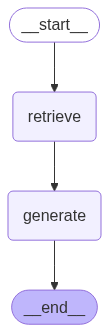

In [46]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [53]:
result = graph.invoke({"question": "What is Task Decomposition?"})

print(f'Context: {result["context"]}\n\n')
print(f'Answer: {result["answer"]}')

Context: [Document(id='75946a2d-a60d-4400-81c2-48b5208abc3e', metadata={'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/'}, page_content='Task decomposition can be done (1) by LLM with simple prompting like "Steps for XYZ.\\n1.", "What are the subgoals for achieving XYZ?", (2) by using task-specific instructions; e.g.'), Document(id='46c25e92-9499-441d-8b33-336fa1720224', metadata={'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/'}, page_content='Task Decomposition#\nChain of thought (CoT; Wei et al.'), Document(id='967b6857-5183-4d5c-bccb-7c810eef9f61', metadata={'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/'}, page_content='Challenges in long-term planning and task decomposition: Planning over a lengthy history and effectively exploring the solution space remain challenging.'), Document(id='9f16570d-1c4a-49bf-8ca0-458f8834e56e', metadata={'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/'}, page_content='The model is instr

## Melhorias no fluxo de estados

Agora que já temos o fluxo de estados, podemos adicionar mais camadas de processamento, como por exemplo, fazer uma análise dos textos antes de gerar a resposta. Para isso, vamos criar uma nova função que irá fazer essa análise e adicionar essa função no fluxo de estados. Para isso vamos criar algumas funções que irão fazer essa análise e adicionar essas funções no fluxo de estados.

1. **Análise da pergunta**: Essa função irá fazer uma análise da pergunta feita pelo usuário, e irá retornar essa análise na chave `query`. Essa função irá utilizar o _prompt_ para fazer essa análise;
2. **Recuperação dos textos**: Essa função irá fazer a recuperação dos textos que mais se adequam à pergunta feita pelo usuário. Essa função irá utilizar o vetor de comparação para buscar os textos que mais se adequam à pergunta, e irá retornar esses textos na chave `context`;
3. **Geração da resposta**: Essa função irá fazer a geração da resposta. Essa função irá utilizar o _prompt_ e a chave `context` para gerar a resposta, e irá retornar essa resposta na chave `answer`;
4. **Estruturação do fluxo de estados**: Essa função irá estruturar o fluxo de estados, onde definimos cada ponto que o RAG irá fazer, podendo adicionar mais camadas, e não somente a recuperação e a geração da resposta;
5. **Adição de metadados**: Essa função irá adicionar metadados aos textos, para que possamos fazer uma filtragem dos textos que mais se adequam à pergunta feita pelo usuário. Essa função irá utilizar o vetor de comparação para buscar os textos que mais se adequam à pergunta, e irá retornar esses textos na chave `context`;

In [48]:
total_documents = len(texts)
third = total_documents // 3

for i, document in enumerate(texts):
    if i < third:
        document.metadata["section"] = "beginning"
    elif i < 2 * third:
        document.metadata["section"] = "middle"
    else:
        document.metadata["section"] = "end"

texts[0].metadata

{'source': 'https://lilianweng.github.io/posts/2023-10-25-adv-attack-llm/',
 'section': 'beginning'}

In [49]:
from typing import Literal
from typing_extensions import Annotated

class Search(TypedDict):
    """Search query."""

    query: Annotated[str, ..., "Search query to run."]
    section: Annotated[
        Literal["beginning", "middle", "end"],
        ...,
        "Section to query.",
    ]

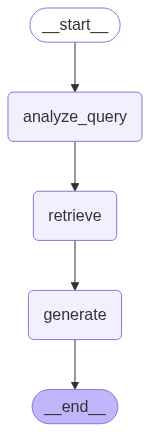

In [50]:
class State(TypedDict):
    question: str
    query: Search
    context: List[Document]
    answer: str

def analyze_query(state: State):
    structured_llm = llm.with_structured_output(Search)
    query = structured_llm.invoke(state["question"])
    return {"query": query}

def retrieve(state: State):
    query = state["query"]
    retrieved_docs = vector_store.similarity_search(
        query["query"],
        filter=lambda doc: doc.metadata.get("section") == query["section"],
    )
    return {"context": retrieved_docs}

def generate(state: State):
    docs_content = "\n\n".join(doc.page_content for doc in state["context"])
    messages = prompt.invoke({"question": state["question"], "context": docs_content})
    response = llm.invoke(messages)
    return {"answer": response.content}

graph_builder = StateGraph(State).add_sequence([analyze_query, retrieve, generate])
graph_builder.add_edge(START, "analyze_query")
graph = graph_builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

In [54]:
for step in graph.stream(
    {"question": "What does the end of the post say about Task Decomposition?"},
    stream_mode="updates",
):
    print(f"{step}\n\n----------------\n")

{'retrieve': {'context': [Document(id='46c25e92-9499-441d-8b33-336fa1720224', metadata={'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/'}, page_content='Task Decomposition#\nChain of thought (CoT; Wei et al.'), Document(id='75946a2d-a60d-4400-81c2-48b5208abc3e', metadata={'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/'}, page_content='Task decomposition can be done (1) by LLM with simple prompting like "Steps for XYZ.\\n1.", "What are the subgoals for achieving XYZ?", (2) by using task-specific instructions; e.g.'), Document(id='0d00601d-e399-4312-8ced-102d48f66284', metadata={'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/'}, page_content='It first decomposes the problem into multiple thought steps and generates multiple thoughts per step, creating a tree structure.'), Document(id='9f16570d-1c4a-49bf-8ca0-458f8834e56e', metadata={'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/'}, page_content='The model is instructed to 

## Melhorias adicionais com agentes e retrievers

Por fim, podemos adicionar mais funcionalidades ao nosso RAG, um bom começo são os exemplos apresentados no site https://python.langchain.com/docs/tutorials/qa_chat_history/